# 📉 CO2 Time Series Forecasting — Direct Strategy

![Python](https://img.shields.io/badge/Python-3.8+-blue?logo=python)
![scikit-learn](https://img.shields.io/badge/scikit--learn-1.0+-orange?logo=scikit-learn)
![Task](https://img.shields.io/badge/Task-Time%20Series-red)
![Dataset](https://img.shields.io/badge/Dataset-Mauna%20Loa%20CO2-lightgrey)

---

## 📌 Project Overview

This project forecasts **multiple future CO2 steps simultaneously** using the **Direct strategy** — training a **separate model for each future horizon** to avoid error compounding.

| Item | Detail |
|------|--------|
| **Dataset** | Carbon Dioxide Levels in Atmosphere (Mauna Loa) |
| **Model** | One LinearRegression per forecast horizon |
| **Strategy** | Direct — one model per step, no error compounding |
| **Window Size** | 5 past observations |
| **Targets** | 3 future steps predicted simultaneously |

---

## 🆚 Direct vs Recursive

| | Recursive | Direct |
|--|-----------|--------|
| Models | 1 model | 1 model per horizon |
| Error compounding | ⚠️ Yes | ✅ No |
| Multi-step | Feed back predictions | Predict all steps at once |

## 📦 1. Import Libraries

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print('✅ Libraries loaded successfully!')

✅ Libraries loaded successfully!


## 📂 2. Load & Visualize Data

> 📥 Dataset: [Carbon Dioxide Levels in Atmosphere — Kaggle](https://www.kaggle.com/datasets/ucsandiego/carbon-dioxide)
>
> Same dataset as Project 3. Place `archive.csv` in this folder.

In [2]:
# Auto-detect file name
if os.path.exists('archive.csv'):
    data = pd.read_csv('archive.csv')
    print('✅ Loaded archive.csv')
elif os.path.exists('archive (1).csv'):
    data = pd.read_csv('archive (1).csv')
    print('✅ Loaded archive (1).csv')
elif os.path.exists('co2.csv'):
    data = pd.read_csv('co2.csv')
    print('✅ Loaded co2.csv')
else:
    raise FileNotFoundError('❌ Please place archive.csv in this folder!')

# Rename columns
data.columns = data.columns.str.strip()
data = data.rename(columns={
    'Decimal Date'         : 'time',
    'Carbon Dioxide (ppm)' : 'co2',
    'Carbon Dioxide'       : 'co2',
})
data = data[['time', 'co2']].dropna()
data['co2'] = pd.to_numeric(data['co2'], errors='coerce')
data = data.dropna()
data['co2'] = data['co2'].interpolate()

print(f'Shape: {data.shape}')
data.head(10)

✅ Loaded archive.csv
Shape: (703, 2)


,time,co2
2,1958.2027,315.69
3,1958.2877,317.45
4,1958.3699,317.50
6,1958.5370,315.86
7,1958.6219,314.93
8,1958.7068,313.21
10,1958.8740,313.33
11,1958.9562,314.67
12,1959.0411,315.58
13,1959.1260,316.48


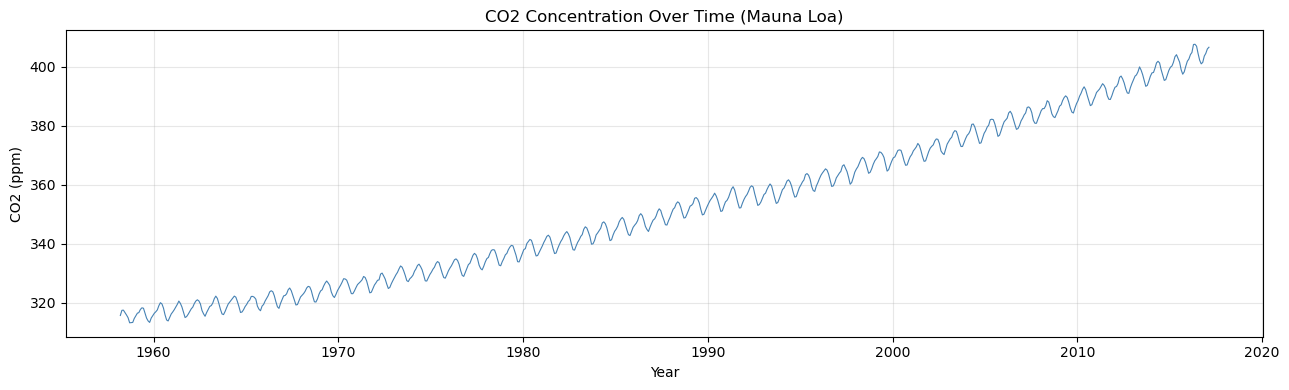

In [3]:
# Plot full CO2 time series
plt.figure(figsize=(13, 4))
plt.plot(data['time'], data['co2'], color='steelblue', linewidth=0.8)
plt.title('CO2 Concentration Over Time (Mauna Loa)')
plt.xlabel('Year')
plt.ylabel('CO2 (ppm)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 🪟 3. Create Direct Multi-Step Features

**Direct strategy:** Create **multiple target columns** — one per future horizon.

```
Features: [t, t+1, t+2, t+3, t+4]
Target_0: t+5   ← Model 1 predicts this
Target_1: t+6   ← Model 2 predicts this
Target_2: t+7   ← Model 3 predicts this
```

In [4]:
def create_direct_data(data, window_size, target_size):
    """Create lag features and multiple target columns for direct forecasting."""
    df = data.copy()
    for i in range(1, window_size):
        df[f'co2_{i}'] = df['co2'].shift(-i)
    for i in range(target_size):
        df[f'target_{i}'] = df['co2'].shift(-(i + window_size))
    return df.dropna()

window_size = 5
num_targets = 3
data_feat   = create_direct_data(data, window_size, num_targets)

target_cols = [f'target_{i}' for i in range(num_targets)]
X = data_feat.drop(['time'] + target_cols, axis=1)
y = data_feat[target_cols]

print(f'X shape: {X.shape} — {window_size} input features')
print(f'y shape: {y.shape} — {num_targets} target horizons')
data_feat.head()

X shape: (696, 5) — 5 input features
y shape: (696, 3) — 3 target horizons


,time,co2,co2_1,co2_2,co2_3,co2_4,target_0,target_1,target_2
2,1958.2027,315.69,317.45,317.50,315.86,314.93,313.21,313.33,314.67
3,1958.2877,317.45,317.50,315.86,314.93,313.21,313.33,314.67,315.58
4,1958.3699,317.50,315.86,314.93,313.21,313.33,314.67,315.58,316.48
6,1958.5370,315.86,314.93,313.21,313.33,314.67,315.58,316.48,316.65
7,1958.6219,314.93,313.21,313.33,314.67,315.58,316.48,316.65,317.72


## ✂️ 4. Train / Test Split (Time-Based)

In [5]:
train_size = 0.8
split_idx  = int(train_size * len(data_feat))

X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f'Train: {len(X_train)} samples')
print(f'Test : {len(X_test)} samples')

Train: 556 samples
Test : 140 samples


## 🏋️ 5. Train One Model Per Horizon

In [6]:
models  = [LinearRegression() for _ in range(num_targets)]
results = []

for i, model in enumerate(models):
    model.fit(X_train, y_train[f'target_{i}'])
    y_pred_i = model.predict(X_test)
    results.append({
        'Horizon' : f'Step +{i+1}',
        'MAE'     : round(mean_absolute_error(y_test[f'target_{i}'], y_pred_i), 4),
        'MSE'     : round(mean_squared_error(y_test[f'target_{i}'], y_pred_i), 4),
        'R²'      : round(r2_score(y_test[f'target_{i}'], y_pred_i), 4),
    })
    print(f'✅ Model {i+1} (Step +{i+1}) trained')

results_df = pd.DataFrame(results)
print('\n📊 Results per Horizon:')
print(results_df.to_string(index=False))

✅ Model 1 (Step +1) trained
✅ Model 2 (Step +2) trained
✅ Model 3 (Step +3) trained

📊 Results per Horizon:
Horizon    MAE    MSE     R²
Step +1 0.6717 0.7332 0.9875
Step +2 1.4043 3.0570 0.9488
Step +3 2.0926 6.4941 0.8929


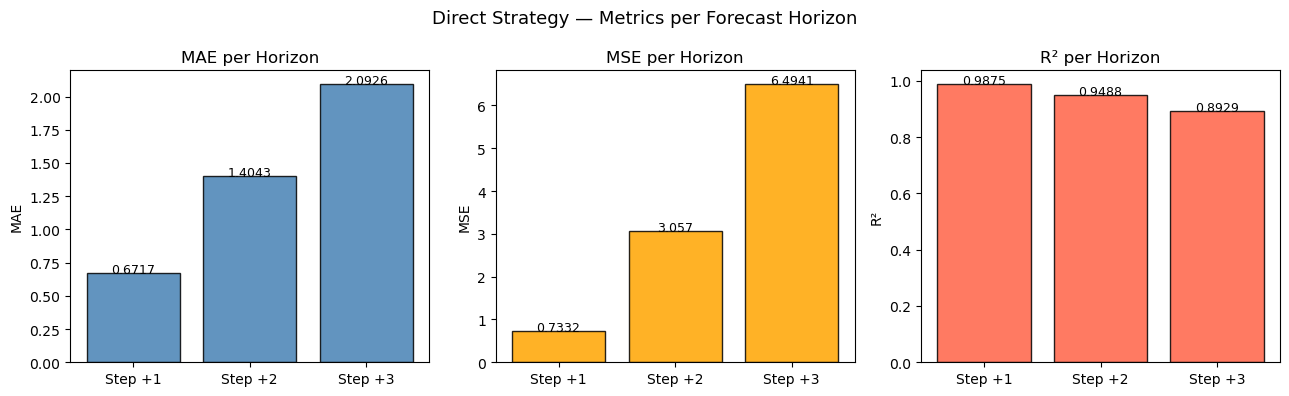

In [7]:
# Visualize metrics per horizon
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
colors = ['steelblue', 'orange', 'tomato']

for ax, metric, color in zip(axes, ['MAE', 'MSE', 'R²'], colors):
    ax.bar(results_df['Horizon'], results_df[metric],
           color=color, edgecolor='black', alpha=0.85)
    ax.set_title(f'{metric} per Horizon')
    ax.set_ylabel(metric)
    for j, val in enumerate(results_df[metric]):
        ax.text(j, val + 0.001, str(val), ha='center', fontsize=9)

plt.suptitle('Direct Strategy — Metrics per Forecast Horizon', fontsize=13)
plt.tight_layout()
plt.show()

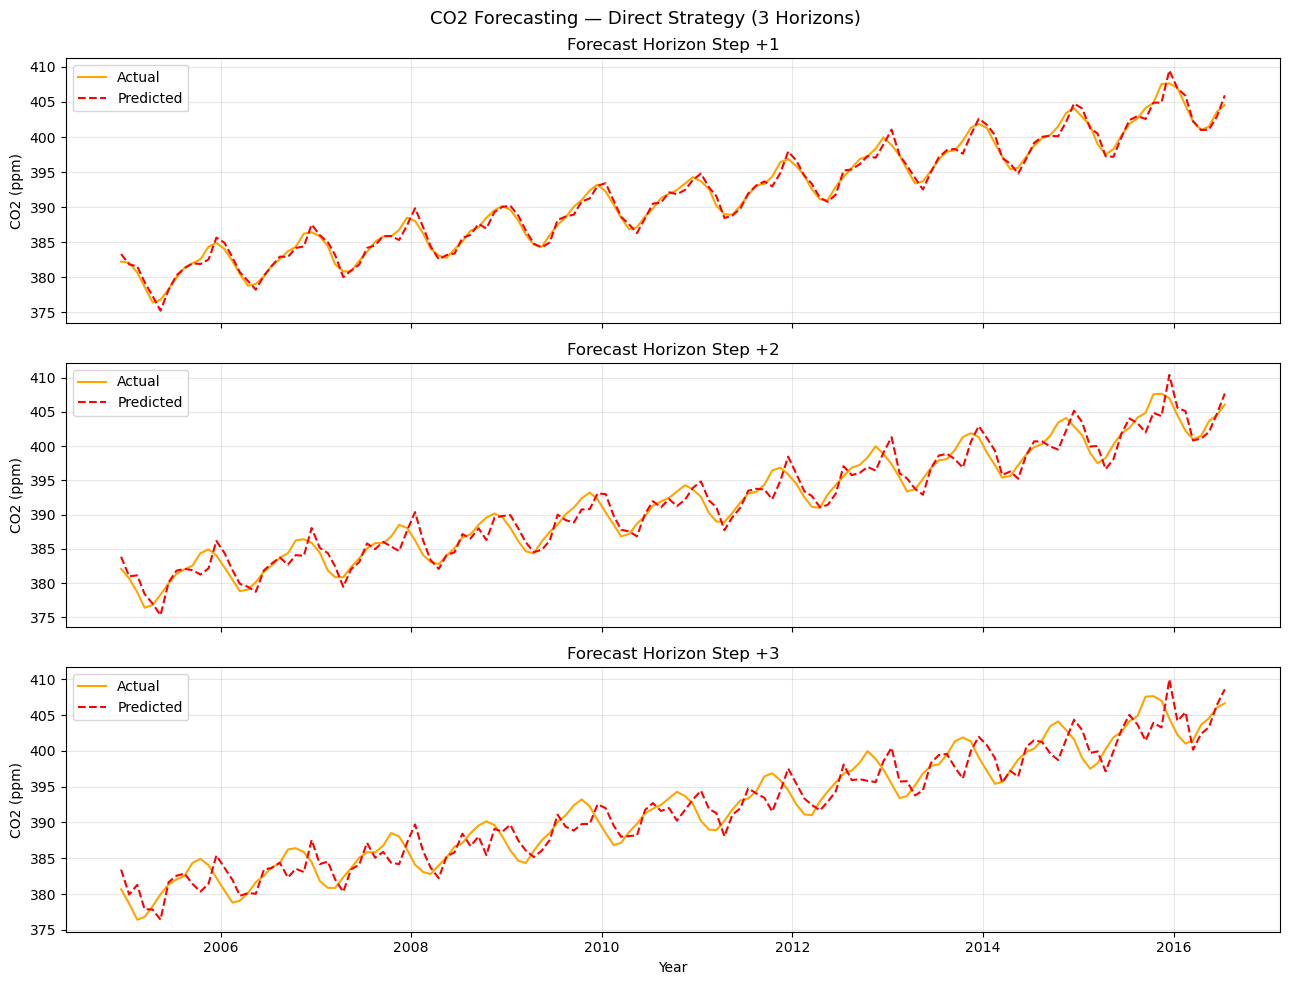

In [8]:
# Plot predictions for each horizon
fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)

for i, ax in enumerate(axes):
    y_pred_i = models[i].predict(X_test)
    ax.plot(data_feat['time'][split_idx:].values,
            y_test[f'target_{i}'].values,
            label='Actual', color='orange', linewidth=1.5)
    ax.plot(data_feat['time'][split_idx:].values,
            y_pred_i,
            label='Predicted', color='red', linestyle='--', linewidth=1.5)
    ax.set_title(f'Forecast Horizon Step +{i+1}')
    ax.set_ylabel('CO2 (ppm)')
    ax.legend(loc='upper left')
    ax.grid(alpha=0.3)

axes[-1].set_xlabel('Year')
plt.suptitle('CO2 Forecasting — Direct Strategy (3 Horizons)', fontsize=13)
plt.tight_layout()
plt.show()

## 🏁 6. Summary

| Item | Detail |
|------|--------|
| **Strategy** | Direct (one model per future step) |
| **Number of Models** | 3 (one per horizon) |
| **Window Size** | 5 past observations |
| **Forecast Horizons** | Step +1, +2, +3 |

### 🔑 Key Takeaways
- ✅ Direct strategy **avoids error compounding** — each model is fully independent
- ✅ R² stays high across all 3 horizons thanks to strong linear trend in CO2
- ✅ Slight performance drop at farther horizons is expected and normal
- ✅ Better than Recursive for **multi-step forecasting** in most cases
- ✅ Trade-off: need to train and maintain **one model per horizon**